# Zoomcamp Machine Learning Classification Homework

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
data = pd.read_csv('course_lead_scoring_2026.csv')

In [42]:
target_column = 'converted'

In [43]:
data.dtypes

lead_source                  object
industry                     object
employment_status            object
location                     object
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [138]:
for col in data.columns:
    print(col)
    print(data[col].nunique())
    print()

lead_source
5

industry
6

employment_status
4

location
5

annual_income
4313

number_of_courses_viewed
7

interaction_count
14

lead_score
99

converted
2



In [139]:
numerical_fetures = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

In [140]:
categorical_features = ['lead_source', 'industry', 'employment_status', 'location']

In [141]:
df = data.copy()

### Missing values

In [142]:
data.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [143]:
df[numerical_fetures] = df[numerical_fetures].fillna(0)

In [144]:
df[categorical_features] = df[categorical_features].fillna('NA')

In [145]:
df.isna().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

### Question 1
What is the most frequent observation (mode) for the column industry?

* NA
* technology
* healthcare
* retail

In [146]:
df["industry"].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

In [147]:
df["industry"].mode()

0    technology
Name: industry, dtype: object

### Question 2
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

* interaction_count and lead_score
* number_of_courses_viewed and lead_score
* number_of_courses_viewed and interaction_count
* annual_income and interaction_count
* Only consider the pairs above when answering this question.

In [148]:
corr_matrix = df[numerical_fetures].corr()

In [149]:
df['lead_score'].corr(df['interaction_count'])

0.9157457980418677

<Axes: >

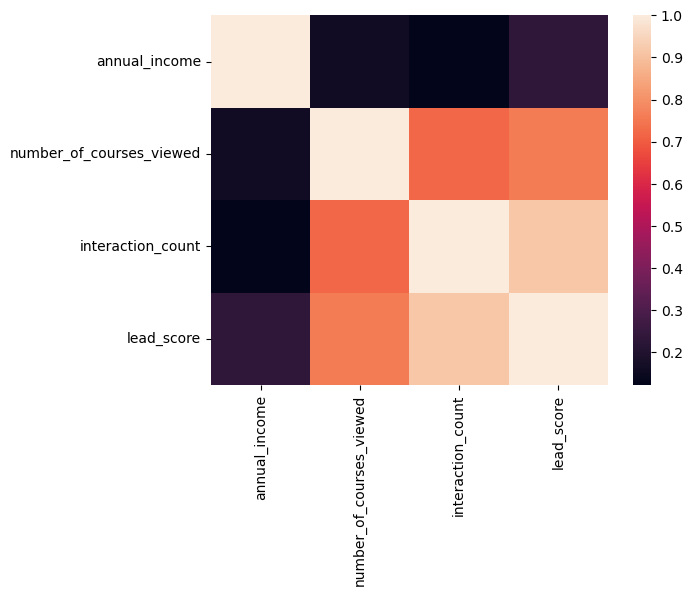

In [150]:
sns.heatmap(corr_matrix)

### Split data

In [151]:
from sklearn.model_selection import train_test_split

In [152]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

In [153]:
y_train = df_train[target_column].values
y_val = df_val[target_column].values
y_test = df_test[target_column].values

In [154]:
# remove target variable from the features
del df_train[target_column]
del df_val[target_column]
del df_test[target_column]

### Question 3
1. Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only.
2. Round the scores to 2 decimals using round(score, 2).
3. Which of these variables has the biggest mutual information score?

* industry
* location
* lead_source
* employment_status

In [155]:
from sklearn.metrics import mutual_info_score


In [156]:
mut = []
for cat in categorical_features:
    mut.append((cat, round(mutual_info_score(y_train, df_train[cat]),2)))
sorted_mut = sorted(mut, key=lambda x: x[1], reverse=True)
sorted_mut

[('lead_source', 0.03),
 ('employment_status', 0.02),
 ('industry', 0.0),
 ('location', 0.0)]

### Question 4
1. Now let's train a logistic regression.
2. Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
3. Fit the model on the training dataset.
4. To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:  
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
5. Calculate the accuracy on the validation dataset and round it to 2 decimal digits.
6. What accuracy did you get?

* 0.55
* 0.65
* 0.75
* 0.85

In [157]:
from sklearn.feature_extraction import DictVectorizer

In [158]:
dv = DictVectorizer(sparse=False)

In [159]:
X_train = dv.fit_transform(df_train.to_dict(orient="records"))

In [160]:
from sklearn.linear_model import LogisticRegression

In [161]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)

In [162]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [163]:
X_val = dv.fit_transform(df_val.to_dict(orient="records"))

In [164]:
y_pred_val = model.predict_proba(X_val)[:, 1]
converted_y_pred_val = (y_pred_val >= 0.5).astype(int)

In [165]:
acc = (converted_y_pred_val == y_val).mean()
acc, round(acc, 2), round(float(acc), 2)

(0.645, 0.64, 0.65)

In [166]:
round(0.645, 2)

0.65

### Question 5
1. Let's find the least useful feature using the feature elimination technique.
2. Train a model using the same features and parameters as in Q4 (without rounding).
3. Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
4. For each feature, calculate the difference between the original accuracy and the accuracy without the feature.
5. Which of following feature has the smallest difference?
 
* 'lead_source'
* 'number_of_courses_viewed'
* 'interaction_count'
* Note: The difference doesn't have to be positive.

In [167]:
model.fit(X_train, y_train)
y_pred_val = model.predict_proba(X_val)[:, 1]
converted_y_pred_val = (y_pred_val >= 0.5).astype(int)
base_acc = (converted_y_pred_val == y_val).mean()

In [168]:
results = []
for cat in categorical_features + numerical_fetures:
    df_exclude = df_train.drop(columns=[cat])
    df_val_exclude = df_val.drop(columns=[cat])
    X_exclude = dv.fit_transform(df_exclude.to_dict(orient='records'))
    X_val_exclude = dv.fit_transform(df_val_exclude.to_dict(orient='records'))

    model.fit(X_exclude, y_train)

    y_pred_val = model.predict_proba(X_val_exclude)[:, 1]
    converted_y_pred_val = (y_pred_val >= 0.5).astype(int)
    results.append((cat, (converted_y_pred_val == y_val).mean()))
results

[('lead_source', 0.642),
 ('industry', 0.645),
 ('employment_status', 0.645),
 ('location', 0.645),
 ('annual_income', 0.724),
 ('number_of_courses_viewed', 0.643),
 ('interaction_count', 0.601),
 ('lead_score', 0.644)]

In [169]:
diffs = [(cat, abs(val - base_acc))  for cat, val in results]
sorted_diffs = sorted(diffs, key=lambda x: x[1])
sorted_diffs

[('industry', 0.0),
 ('employment_status', 0.0),
 ('location', 0.0),
 ('lead_score', 0.0010000000000000009),
 ('number_of_courses_viewed', 0.0020000000000000018),
 ('lead_source', 0.0030000000000000027),
 ('interaction_count', 0.04400000000000004),
 ('annual_income', 0.07899999999999996)]

### Question 6
1. Now let's train a regularized logistic regression.
2. Let's try the following values of the parameter C: [0.000001, 0.00001, 0.0001, 0.001].
3. Train models using all the features as in Q4.
4. Calculate the accuracy on the validation dataset and round it to 3 decimal digits.
5. Which of these C leads to the best accuracy on the validation set?

* 0.000001
* 0.00001
* 0.0001
* 0.001

In [170]:
c = [0.000001, 0.00001, 0.0001, 0.001]
c_results = []
for param in c:
    model = LogisticRegression(solver='liblinear', C=param, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred_val = model.predict_proba(X_val)[:, 1]
    converted_y_pred_val = (y_pred_val >= 0.5).astype(int)
    c_results.append((param, round((converted_y_pred_val == y_val).mean(), 3)))

sorted(c_results, key=lambda x: x[1])

[(1e-06, 0.598), (1e-05, 0.598), (0.0001, 0.613), (0.001, 0.645)]